# Imports


In [ ]:
# Turn on autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Import statements
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from loguru import logger
from nibabel import processing

from mnutils import plotting, utils

logger.remove()
logger.add(sys.stdout, level="INFO")

/home/sbauer/Projects/Coding/FOSS/MNUtils/.venv/lib/python3.12/site-packages/hlsvdpro/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


1

# Close any open figures


In [3]:
# Close any open figures
plt.close("all")

# Load data


In [4]:
BASE_FOLDER = Path(os.getcwd()) / "datasets" / "20250408-NIST-Mag2"
DATA_FOLDER = BASE_FOLDER / "data"
SERIES_T1 = 2
SERIES_MRSI = 5

In [5]:
from mnutils import GESeries

MRSI_exp = GESeries.MRSISeries(DATA_FOLDER, SERIES_MRSI)
T1_exp = GESeries.MRISeries(DATA_FOLDER, SERIES_T1)

In [6]:
resampled_MRSI = MRSI_exp.resample_self_to(T1_exp.nii, order=0)
resampled_blocky_MRSI = MRSI_exp.RAW_exp.resample_self_to(T1_exp.nii, order=0)

In [7]:
# resample_kwargs = {"half_voxel_shift": True}

# T1_exp.display(cmap="gray")

interactive(children=(IntSlider(value=37, description='slice_idx', max=75), Output()), _dom_classes=('widget-i…

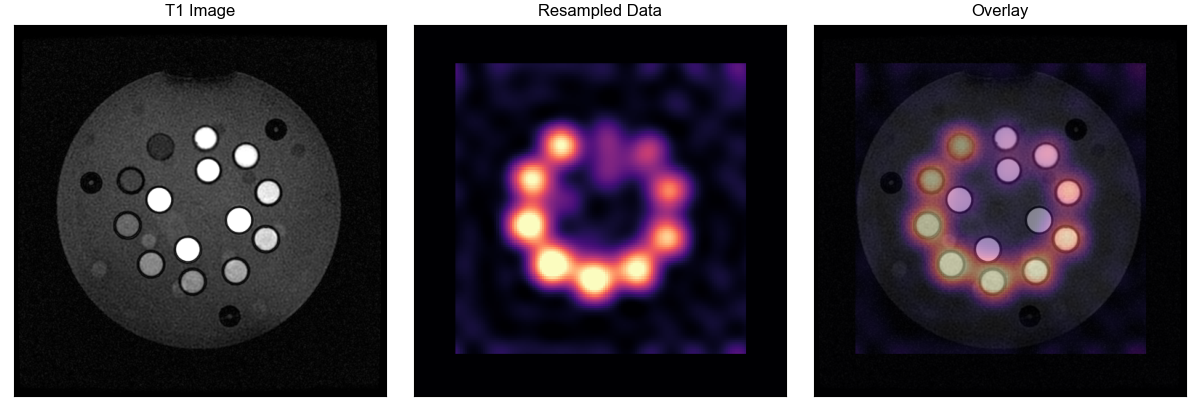

In [8]:
MRSI_exp.overlay_on_T1(T1_exp)

interactive(children=(IntSlider(value=37, description='slice_idx', max=75), Output()), _dom_classes=('widget-i…

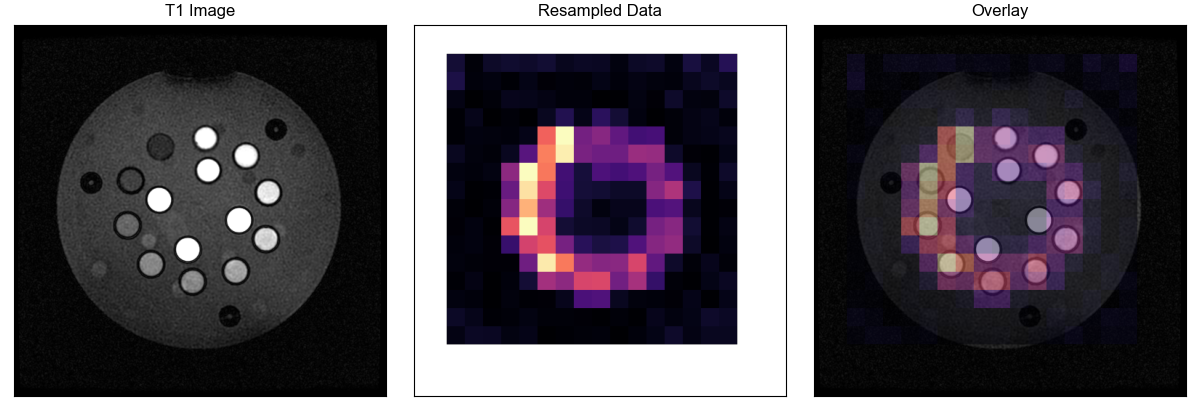

In [9]:
# Quickly check custom affine creation
blocky_MRSI = MRSI_exp.create_MRSI_nii()
blocky_MRSI.overlay_on_T1(T1_exp)

### Save blocky MRSI

Use built in function to save blocky MRSI


In [10]:
series_folder = MRSI_exp.nii_path.parent
output_path = series_folder / f"{MRSI_exp.SERIES_ID}_MRSI_resampled_lowres.nii.gz"
if not output_path.exists():
    blocky_MRSI.save(output_path)
else:
    logger.info(f"File {output_path} already exists, skipping save.")

2026-08-12 14:46:41.796 | INFO     | __main__:<module>:6 - File /home/sbauer/Projects/Coding/FOSS/MNUtils/tests/datasets/20250408-NIST-Mag2/data/005_MRSI_pseudo_S700_X10_Y10_Z10_T1_C1/5_MRSI_resampled_lowres.nii.gz already exists, skipping save.


In [11]:
# Create half voxel shifted blocky MRSI
half_voxel_shifted_blocky_affine = MRSI_exp.create_MRSI_affine()
half_voxel_shifted_blocky_affine[0:2, 3] -= MRSI_exp.voxel_size / 2

half_voxel_shifted_MRSI = blocky_MRSI.with_new_data(blocky_MRSI.images())
half_voxel_shifted_MRSI.nii._affine = half_voxel_shifted_blocky_affine

output_path_half_voxel = (
    series_folder
    / f"{MRSI_exp.SERIES_ID}_MRSI_resampled_lowres_half_voxel_shifted.nii.gz"
)
if not output_path_half_voxel.exists():
    half_voxel_shifted_MRSI.save(output_path_half_voxel)
else:
    logger.info(f"File already exists, skipping save.\n{output_path_half_voxel}")

2026-08-12 14:46:41.821 | INFO     | __main__:<module>:15 - File already exists, skipping save.
/home/sbauer/Projects/Coding/FOSS/MNUtils/tests/datasets/20250408-NIST-Mag2/data/005_MRSI_pseudo_S700_X10_Y10_Z10_T1_C1/5_MRSI_resampled_lowres_half_voxel_shifted.nii.gz


In [ ]:
# Create itksnap command with both T1 and MRSI
itksnap_command = (
    f"itksnap -g {T1_exp.nii_path} -o {MRSI_exp.nii_path} "
    f"{output_path} {output_path_half_voxel}"
)
logger.info(
    f"Run the following command to visualize in ITK-SNAP:\n\n{itksnap_command}\n\n"
    "Check that the MRSI overly looks properly placed and no half voxel shifts are visible."
)

## Create check with mask


2026-08-12 14:46:41.879 | INFO     | __main__:<module>:6 - Mask shape: (128, 128, 16), dtype: bool, unique values: [False  True]


interactive(children=(IntSlider(value=37, description='slice_idx', max=75), Output()), _dom_classes=('widget-i…

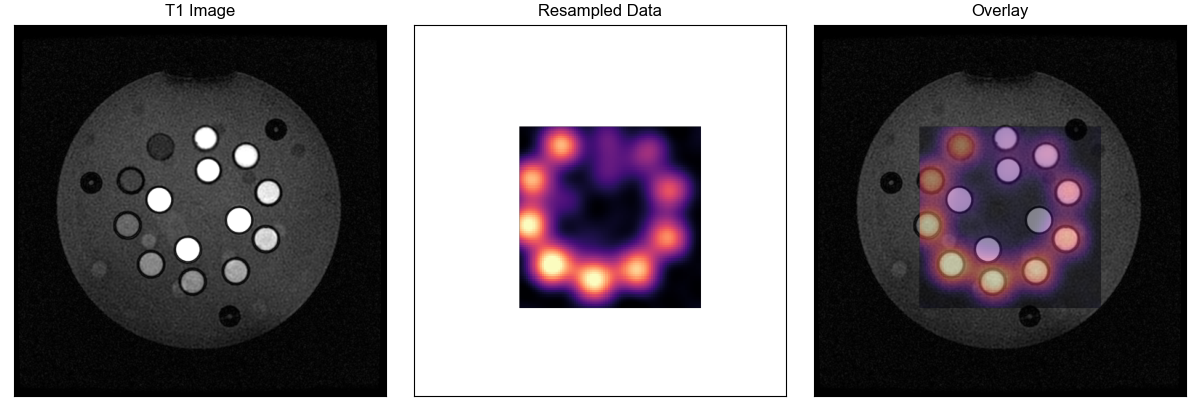

In [13]:
import numpy as np

mask = np.full_like(MRSI_exp.images(), False, dtype=bool)
# Set the
mask[20:100, 20:100, 4:8] = True
logger.info(
    f"Mask shape: {mask.shape}, dtype: {mask.dtype}, unique values: {np.unique(mask)}"
)

MRSI_exp.overlay_on_T1(T1_exp, mask=mask, mask_contour=True)

In [14]:
logger.info(
    f"Mask instance check: {isinstance(mask, np.ndarray)}, dtype check: {mask.dtype == np.bool_}"
)
if not isinstance(mask, np.ndarray) or mask.dtype != np.bool_:
    raise ValueError("Mask must be a numpy array of boolean type.")


2026-08-12 14:46:42.950 | INFO     | __main__:<module>:1 - Mask instance check: True, dtype check: True


# Sandbox: fake-data orientation / resampling / overlay

Self-contained investigation area. **Does not import `mnutils`** — it uses standalone
copies of `orient_nifti`, `get_display_affine`, `resample_nifti`, and the voxel-box
geometry, so your main code stays untouched.

**Functions are separated from input**: edit only the **INPUT / CONFIG** cell (shapes,
voxel sizes, origins, `ORIENTATION`, `HALF_VOXEL_SHIFT`) and re-run cells 4–6.

Pipeline: build fake T1 + MRSI → resample MRSI onto the T1 grid → orient both →
project voxel boxes through the display affine → overlay. The single **bright MRSI
voxel** is boxed in **yellow** so you can immediately see whether the box lands on the
resampled bright block. Toggle `HALF_VOXEL_SHIFT = True` to watch the block slide off
its box by half a voxel.


In [ ]:
# ---------------------------------------------------------------------
# 2. STANDALONE FUNCTIONS (copies of mnutils — do NOT import mnutils here)
#    Edit these to investigate; main code is untouched.
# ---------------------------------------------------------------------
import nibabel as nib
import numpy as np
from nibabel import affines
from nibabel import orientations as ornt


def orient_array(nii, orientation=("L", "P", "S")):
    """Copy of utils.nifti.orient_nifti.

    Reorient to `orientation`, then transpose axes 0/1 for display.
    Note: flipud(rot90(k=1, axes=(0,1))) == swapaxes(0, 1) exactly.
    """
    data = np.asarray(nii.get_fdata())
    oriented = ornt.apply_orientation(data, ornt.axcodes2ornt(orientation))
    return np.flipud(np.rot90(oriented, k=1, axes=(0, 1)))


def get_display_affine(nii, orientation=("L", "P", "S")):
    """Copy of utils.nifti.get_display_affine.

    Affine mapping display voxel index (after orient_array) -> world mm.
    Bakes the axis-0/1 transpose in via the column-swap P (=> anti-diagonal).
    """
    transform = ornt.ornt_transform(
        ornt.io_orientation(nii.affine), ornt.axcodes2ornt(orientation)
    )
    oriented_affine = np.asarray(nii.as_reoriented(transform).affine, float)
    P = np.eye(4)
    P[0, 0] = P[1, 1] = 0.0
    P[0, 1] = P[1, 0] = 1.0
    return oriented_affine.dot(P)


def resample_to(source_nii, target_nii, order=0):
    """Copy of utils.nifti.resample_nifti (nearest-neighbour, cval=nan)."""
    return processing.resample_from_to(
        source_nii, target_nii, order=order, cval=np.nan, mode="grid-constant"
    )


def voxel_box_xy(voxel, mrsi_to_display_affine):
    """Copy of draw_voxel_overlays_on_ax geometry.

    Project the 4 in-plane corners (index +/-0.5 on axes 0,1) through the FULL
    affine. Returns (4, 2) of (col, row) = (x, y) for a matplotlib Polygon.
    Robust to transposed/rotated display affines (reading the diagonal is not).
    """
    offs = np.array([[-0.5, -0.5, 0], [0.5, -0.5, 0], [0.5, 0.5, 0], [-0.5, 0.5, 0]])
    corners = np.asarray(voxel, float) + offs
    disp = affines.apply_affine(mrsi_to_display_affine, corners)
    return disp[:, [1, 0]]  # (row, col) -> (col, row) = (x, y)

In [16]:
# ---------------------------------------------------------------------
# 3. INPUT / CONFIG  (edit me — nothing above this needs changing)
# ---------------------------------------------------------------------
ORIENTATION = ("L", "P", "S")  # try ("L", "I", "P") etc. to probe orientation
HALF_VOXEL_SHIFT = False  # toggle True to reproduce the shifted overlay

# T1: fine grid
T1_SHAPE = (100, 100, 100)
T1_VOX = (2.0, 2.0, 2.0)  # mm
T1_ORIGIN = (-0.0, -0.0, -50.0)

# MRSI: coarse grid (~10x T1 voxel size), voxel-CENTER origin
# MRSI_SHAPE = np.asarray([10, 10, 10])
# MRSI_VOX = np.asarray([20.0, 20.0, 25.0])  # mm
# MRSI_ORIGIN = (-20.0, -20.0, -50)
MRSI_SHAPE = (np.asarray(T1_SHAPE) / 10).astype(int)
MRSI_VOX = np.asarray(T1_VOX) * 10  #  * [1, 2, 3] * 2  # mm
MRSI_ORIGIN = (
    np.asarray(T1_ORIGIN)
    + 0.5 * MRSI_VOX
    - 0.5 * np.asarray(T1_VOX)
    + np.asarray([0, 0, 0])
)  # voxel-CENTER origin


# Bright MRSI voxel (yellow box); other boxes drawn cyan
BRIGHT_VOXEL = (4, 4, 3)
HIGHLIGHT_VOXELS = [(4, 4, 3), (0, 0, 0), (1, 3, 2)]

In [ ]:
# ---------------------------------------------------------------------
# 4. BUILD FAKE T1 + MRSI SpatialImages (edit make_fake_data pattern if wanted)
# ---------------------------------------------------------------------
def make_affine(vox, origin):
    """Build a diagonal affine from voxel sizes and an origin."""
    A = np.diag([*vox, 1.0]).astype(float)
    A[:3, 3] = origin
    return A


def make_fake_data():
    """Build fake T1 (sphere + bright box) and MRSI (noise + bright voxel) images."""
    t1_aff = make_affine(T1_VOX, T1_ORIGIN)
    mrsi_aff = make_affine(MRSI_VOX, MRSI_ORIGIN)

    # T1: a sphere + a coarse checker so orientation / flips are obvious by eye
    i0, i1, i2 = np.indices(T1_SHAPE)
    c = np.array(T1_SHAPE) / 2.0
    r = np.sqrt((i0 - c[0]) ** 2 + (i1 - c[1]) ** 2 + (i2 - c[2]) ** 2)
    t1 = (r < min(T1_SHAPE) / 2.5).astype(np.float32) * 0.6
    # Place a bright box at 10, 20, 30 that has size 15, 25, 35
    t1[10:25, 20:45, 30:65] = 1.0
    #    x      y      z
    # Add grid-like checker pattern to T1 for visual orientation cues
    # t1 += 0.2 * ((i0 // 2 + i1 // 2) % 2)

    t1_nii = nib.Nifti1Image(t1, t1_aff)

    # MRSI: uniform low background + one BRIGHT voxel to track through the pipeline
    # mrsi = np.random.uniform(0.1, 0.1, MRSI_SHAPE).astype(np.float32)
    mrsi = np.random.default_rng().random(MRSI_SHAPE)
    mrsi[BRIGHT_VOXEL] = 1.0
    mrsi_nii = nib.Nifti1Image(mrsi, mrsi_aff)
    return t1_nii, mrsi_nii


t1_nii, mrsi_nii = make_fake_data()
print("T1 affine\n", t1_nii.affine)
print("MRSI affine\n", mrsi_nii.affine)
print(
    "MRSI bright voxel world centre:",
    affines.apply_affine(mrsi_nii.affine, BRIGHT_VOXEL).round(2),
)

In [18]:
# ---------------------------------------------------------------------
# 5. APPLY PIPELINE (resample -> orient -> build display affine)
# ---------------------------------------------------------------------
resampled_mrsi = resample_to(mrsi_nii, t1_nii, order=0)

t1_disp = orient_array(t1_nii, ORIENTATION)
mrsi_disp = orient_array(resampled_mrsi, ORIENTATION)

display_affine = get_display_affine(t1_nii, ORIENTATION)
mrsi_to_display = np.linalg.inv(display_affine).dot(mrsi_nii.affine)

print("display volume shape:", t1_disp.shape)
print("mrsi_to_display (anti-diagonal when axes 0/1 are transposed):")
print(np.round(mrsi_to_display, 2))

# Display slice at the centre of the bright voxel
slice_idx = int(round(affines.apply_affine(mrsi_to_display, BRIGHT_VOXEL)[2]))
# slice_idx = 50
print(f"bright voxel {BRIGHT_VOXEL} centre -> display slice {slice_idx}")

display volume shape: (100, 100, 100)
mrsi_to_display (anti-diagonal when axes 0/1 are transposed):
[[  0.  -10.    0.   94.5]
 [-10.    0.    0.   94.5]
 [  0.    0.   10.    4.5]
 [  0.    0.    0.    1. ]]
bright voxel (4, 4, 3) centre -> display slice 34


In [19]:
plt.close("all")

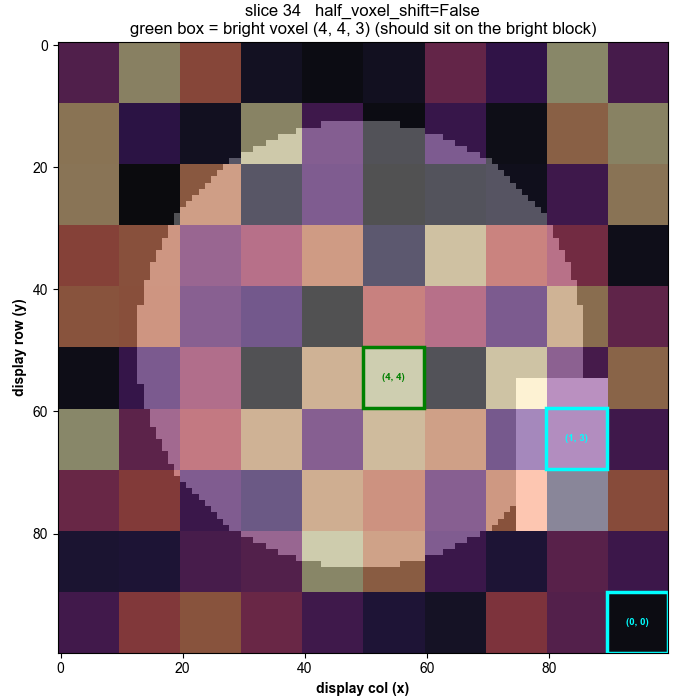

In [20]:
# ---------------------------------------------------------------------
# 6. VISUAL OVERLAY
# ---------------------------------------------------------------------
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(t1_disp[:, :, slice_idx], cmap="gray", origin="upper", vmin=-0.1)
ax.imshow(mrsi_disp[:, :, slice_idx], cmap="magma", alpha=0.5, origin="upper", vmin=0)

for vox in HIGHLIGHT_VOXELS:
    xy = voxel_box_xy(vox, mrsi_to_display)
    is_bright = tuple(vox) == tuple(BRIGHT_VOXEL)
    color = "green" if is_bright else "cyan"
    ax.add_patch(
        mpatches.Polygon(xy, closed=True, fill=False, edgecolor=color, linewidth=2.5)
    )
    ax.text(
        xy[:, 0].mean(),
        xy[:, 1].mean(),
        str(tuple(vox[:2])),
        color=color,
        ha="center",
        va="center",
        fontsize=7,
        fontweight="bold",
    )

ax.set_title(
    f"slice {slice_idx}   half_voxel_shift={HALF_VOXEL_SHIFT}\n"
    f"green box = bright voxel {BRIGHT_VOXEL} (should sit on the bright block)"
)
ax.set_xlabel("display col (x)")
ax.set_ylabel("display row (y)")
plt.show()

# Real data: same pipeline, same functions

Reuses the standalone functions above (`orient_array`, `get_display_affine`,
`resample_to`, `voxel_box_xy`) — now fed the real `T1_exp` / `MRSI_exp` instead of
fake data. Requires the **Load data** cells near the top (that build `T1_exp` and
`MRSI_exp`) to have run.

Same 4-step structure as the sandbox: **R1 config → R2 load → R3 apply → R4 overlay**.
`USE_MRSI = "blocky"` boxes each MRSI voxel (`RAW_exp`); `"fine"` uses the interpolated
grid. The brightest MRSI voxel is boxed in **green** and should sit on the bright
resampled block.


In [21]:
# ---------------------------------------------------------------------
# R1. REAL-DATA CONFIG (edit me — nothing above this needs changing)
# ---------------------------------------------------------------------
ORIENTATION = T1_exp.orientation  # match the main pipeline's orientation
USE_MRSI = "blocky"  # "blocky" -> MRSI_exp.RAW_exp, "fine" -> MRSI_exp
BRIGHT_VOXEL = None  # None -> auto-pick the brightest MRSI voxel
EXTRA_VOXELS = []  # extra boxes as (i, j, k) tuples

In [ ]:
# ---------------------------------------------------------------------
# R2. LOAD REAL DATA (analog of make_fake_data — pulls from the experiments)
# ---------------------------------------------------------------------
t1_nii = T1_exp.nii
if USE_MRSI == "blocky":
    interpolated_voxel_sizes = MRSI_exp.nii.affine[0, 0]
    scaling_factor = MRSI_exp.voxel_size / interpolated_voxel_sizes

    new_affine = np.copy(MRSI_exp.nii.affine)
    new_affine[0, 0] *= scaling_factor
    new_affine[1, 1] *= scaling_factor
    # Round voxel sizes to 3 decimal places to avoid floating point issues
    new_affine[0:3, 0:3] = np.round(new_affine[0:3, 0:3], 3)

    # Offset x and y by centre offset
    # The shift is important as we want to make sure the overlay is in the correct position
    # The correct shift is the following
    shift = (np.diag(new_affine[:3]) - np.diag(MRSI_exp.nii.affine[:3])).round(3) / 2
    # However this creates the correct FOV but the overlay is not in the correct position
    # For a correct shift we need to add an additonal half voxel
    shift += np.array([new_affine[0, 0], new_affine[1, 1], 0]) / 2
    print(
        f"Calculated shift for new affine: {shift}.\n"
        f"Original affine translation: {MRSI_exp.nii.affine[:3, 3]}"
    )
    new_affine[:3, 3] += shift
    data = np.sum(np.abs(MRSI_exp.spec), axis=0).astype(np.float32)
    mrsi_nii = MRSI_exp.with_new_data(data, new_affine).nii
    # mrsi_nii = MRSI_exp.RAW_exp.nii
else:
    mrsi_nii = MRSI_exp.nii


_mrsi_data = np.asarray(mrsi_nii.get_fdata())
BRIGHT_VOXEL = tuple(
    int(v) for v in np.unravel_index(np.nanargmax(_mrsi_data), _mrsi_data.shape)
)
HIGHLIGHT_VOXELS = [BRIGHT_VOXEL] + [tuple(v) for v in EXTRA_VOXELS]

# print("T1 affine\n", np.asarray(t1_nii.affine))
# print("MRSI affine\n", np.asarray(mrsi_nii.affine))
# print("MRSI shape:", _mrsi_data.shape, "  bright voxel:", BRIGHT_VOXEL)
# print(
#     "MRSI bright voxel world centre:",
#     affines.apply_affine(np.asarray(mrsi_nii.affine), BRIGHT_VOXEL).round(2),
# )

In [23]:
print("new_affine:\n", new_affine)
print("MRSI_exp.nii.affine:\n", MRSI_exp.nii.affine)
print("mrsi_nii.affine:\n", mrsi_nii.affine)
print("MRSI_exp.RAW_exp.nii.affine:\n", MRSI_exp.RAW_exp.nii.affine)

new_affine:
 [[ 12.5          0.           0.         -92.77650629]
 [  0.          12.5          0.         -58.79140649]
 [  0.           0.          12.5        -73.00745392]
 [  0.           0.           0.           1.        ]]
MRSI_exp.nii.affine:
 [[   1.5625        0.            0.         -104.49550629]
 [   0.            1.5625        0.          -70.51040649]
 [   0.            0.           12.50000381  -73.00745392]
 [   0.            0.            0.            1.        ]]
mrsi_nii.affine:
 [[ 12.5          0.           0.         -92.77650629]
 [  0.          12.5          0.         -58.79140649]
 [  0.           0.          12.5        -73.00745392]
 [  0.           0.           0.           1.        ]]
MRSI_exp.RAW_exp.nii.affine:
 [[ 12.5          0.           0.         -92.77650629]
 [  0.          12.5          0.         -58.79140649]
 [  0.           0.          12.5        -73.00745392]
 [  0.           0.           0.           1.        ]]


In [24]:
# ---------------------------------------------------------------------
# R3. APPLY PIPELINE (resample -> orient -> build display affine)
#     Same code as sandbox cell 5, same functions.
# ---------------------------------------------------------------------
resampled_mrsi = resample_to(mrsi_nii, t1_nii, order=0)

t1_disp = orient_array(t1_nii, ORIENTATION)
mrsi_disp = orient_array(resampled_mrsi, ORIENTATION)

display_affine = get_display_affine(t1_nii, ORIENTATION)
mrsi_to_display = np.linalg.inv(display_affine).dot(np.asarray(mrsi_nii.affine))

# print("display volume shape:", t1_disp.shape)
# print("mrsi_to_display (anti-diagonal when axes 0/1 are transposed):")
# print(np.round(mrsi_to_display, 2))

slice_idx = int(round(affines.apply_affine(mrsi_to_display, BRIGHT_VOXEL)[2]))
# print(f"bright voxel {BRIGHT_VOXEL} centre -> display slice {slice_idx}")

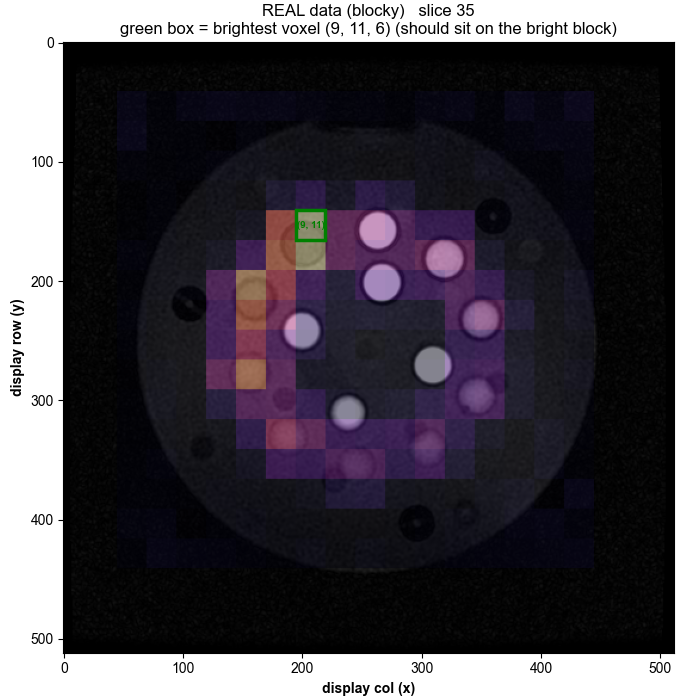

In [25]:
# ---------------------------------------------------------------------
# R4. VISUAL OVERLAY (identical structure to sandbox cell 6)
# ---------------------------------------------------------------------
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

img_vmin, img_vmax = plotting.images.fast_bounds(t1_disp[:, :, slice_idx])

fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(
    t1_disp[:, :, slice_idx], cmap="gray", origin="upper", vmin=img_vmin, vmax=img_vmax
)
ax.imshow(mrsi_disp[:, :, slice_idx], cmap="magma", alpha=0.5, origin="upper", vmin=0)

for vox in HIGHLIGHT_VOXELS:
    xy = voxel_box_xy(vox, mrsi_to_display)
    is_bright = tuple(vox) == tuple(BRIGHT_VOXEL)
    color = "green" if is_bright else "cyan"
    ax.add_patch(
        mpatches.Polygon(xy, closed=True, fill=False, edgecolor=color, linewidth=2.5)
    )
    ax.text(
        xy[:, 0].mean(),
        xy[:, 1].mean(),
        str(tuple(int(v) for v in vox[:2])),
        color=color,
        ha="center",
        va="center",
        fontsize=7,
        fontweight="bold",
    )

ax.set_title(
    f"REAL data ({USE_MRSI})   slice {slice_idx}\n"
    f"green box = brightest voxel {BRIGHT_VOXEL} (should sit on the bright block)"
)
ax.set_xlabel("display col (x)")
ax.set_ylabel("display row (y)")
plt.show()

[]

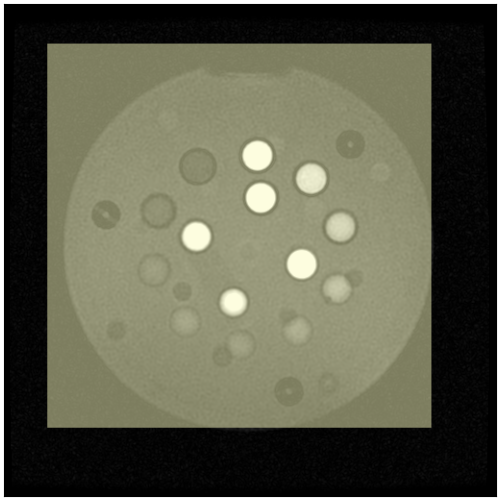

In [26]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.imshow(
    t1_disp[:, :, slice_idx], cmap="gray", origin="upper", vmin=img_vmin, vmax=img_vmax
)
ax.imshow(
    mrsi_disp[:, :, slice_idx], cmap="magma", alpha=0.5, origin="upper", vmin=0, vmax=20
)
# Remove all ticks
ax.set_xticks([])
ax.set_yticks([])

See tests/FOV-Overlay.png for DICOM FOV overlay. The green extent is the dicom true value -> Should needs to match above plot


![FOV-Overlay](FOV-Overlay.png)


# Now check that this also works in my code


(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'Anatomical Slice 39'}>)

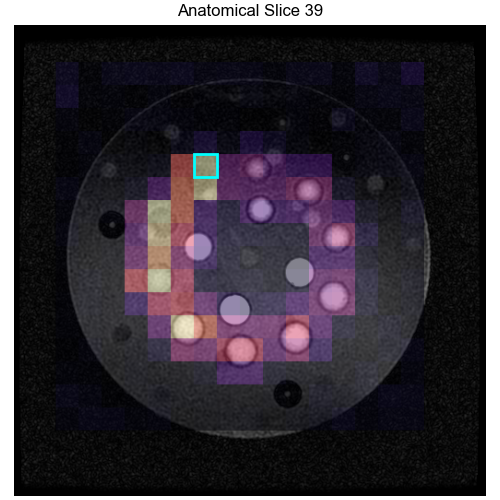

In [27]:
plotting.images.overlay_voxel_on_T1(T1_exp, MRSI_exp, (9, 11, 7), figsize=(5, 5))

# Check that inspect MRSI spectra works properly


## Check on existing example data with NIST phantom


In [28]:
plotting.images.inspect_MRSI_spectra(
    T1_exp,
    MRSI_exp,
)

## Check with Brain DMI scan


In [29]:
DATASET_FOLDER = BASE_FOLDER.parent
BRAIN_DATA_FOLDER = DATASET_FOLDER / "HeVo-18" / "data"


Brain_SERIES_T1 = 2
Brain_SERIES_MRSI = 8

Brain_MRSI_exp = GESeries.MRSISeries(BRAIN_DATA_FOLDER, Brain_SERIES_MRSI)
Brain_T1_exp = GESeries.MRISeries(BRAIN_DATA_FOLDER, Brain_SERIES_T1)

In [30]:
plotting.images.inspect_MRSI_spectra(Brain_T1_exp, Brain_MRSI_exp)

## Check with abdominal DMI scan


In [31]:
# Load data from other project
ABDO_DATA_FOLDER = (
    BASE_FOLDER.parent.parent.parent.parent.parent
    / "PhD Projects"
    / "IV_DMI"
    / "datasets"
    / "HeVo-13"
    / "data"
)

ABDO_SERIES_T1 = 4
ABDO_SERIES_MRSI = 10

ABDO_MRSI_exp = GESeries.MRSISeries(ABDO_DATA_FOLDER, ABDO_SERIES_MRSI)
ABDO_T1_exp = GESeries.MRISeries(ABDO_DATA_FOLDER, ABDO_SERIES_T1)

In [32]:
plotting.images.inspect_MRSI_spectra(ABDO_T1_exp, ABDO_MRSI_exp)

# Doc: display voxels when the images are bounded (cropped)

When you crop the anatomical/MRSI display images to a sub-region (e.g. `images(...)[y_slice, x_slice, z]`)
for a tighter figure, the voxel boxes from `draw_voxel_overlays_on_ax` are still computed in the
**full, uncropped display coordinate system** (they only depend on `mrsi_to_display_affine`, not on
the image array you plotted). So after drawing, shift each returned `Polygon` by the crop's
`(x_offset, y_offset)` = `(x_slice.start, y_slice.start)` to bring it back into the cropped axes.

1. Build `mrsi_to_display_affine = inv(get_display_affine(T1)) @ MRSI.RAW_exp.nii.affine`.
2. Crop both anatomical and (resampled) MRSI images with the same `(y_slice, x_slice, z)` bounds.
3. Plot the cropped images with `overlay_image_data_on_T1_on_ax`.
4. Draw voxel box(es) with `draw_voxel_overlays_on_ax(ax, voxel, mrsi_to_display_affine, ...)`.
5. Shift each patch: `patch.set_xy(patch.get_xy() - np.array([x_offset, y_offset]))`.


In [ ]:
import numpy as np

# ---------------------------------------------------------------------
# 1. Resample MRSI onto the T1 grid and orient both volumes (full FOV).
#    Use the abdominal exam so we can reuse the liver voxel from
#    image_abdomen_single_voxels.ipynb.
# ---------------------------------------------------------------------
t1_full_images, mrsi_full_images = utils.nifti.resample_and_orient_nifti(
    source_nii=ABDO_MRSI_exp.RAW_exp.nii,
    target_nii=ABDO_T1_exp.nii,
)

display_affine = utils.nifti.get_display_affine(ABDO_T1_exp.nii)
mrsi_to_display_affine = np.linalg.inv(display_affine).dot(
    np.asarray(ABDO_MRSI_exp.RAW_exp.nii.affine)
)


def spec_to_voxel(spec_location, dims):
    """Convert a spectroscopy (x, y, z) location to a display voxel index."""
    x, y, z = spec_location
    dim_x, dim_y, _ = dims
    return (dim_y - y - 1, dim_x - x - 1, z)


# Same liver voxel/slice as image_abdomen_single_voxels.ipynb
LIVER_ANATOMICAL_SLICE = 46  # ID 47 in dicom series
liver_spec_location = (7, 6, 7)
demo_voxel = spec_to_voxel(liver_spec_location, ABDO_MRSI_exp.dims)
slice_idx = LIVER_ANATOMICAL_SLICE

print(f"Demo voxel {demo_voxel} -> display slice {slice_idx}")

## Bound (crop) the images, then correct the voxel box offset

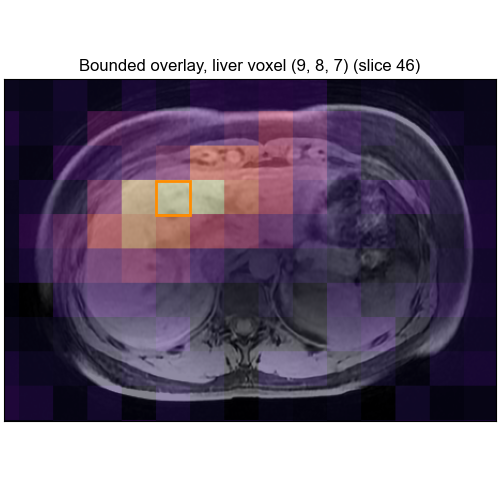

In [34]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 2. Crop ("bound") the display images to a sub-region for a tighter figure.
#    IMPORTANT: draw_voxel_overlays_on_ax always works in FULL display
#    coordinates, so the resulting patch must be shifted by (x_offset, y_offset).
# ---------------------------------------------------------------------
y_slice = slice(105, 425)
x_slice = slice(30, 490)
x_offset, y_offset = x_slice.start, y_slice.start

t1_crop = t1_full_images[y_slice, x_slice, slice_idx]
mrsi_crop = mrsi_full_images[y_slice, x_slice, slice_idx]

fig, ax = plt.subplots(figsize=(5, 5))
plotting.images.overlay_image_data_on_T1_on_ax(ax, t1_crop, mrsi_crop, aspect=1)

(patch,) = plotting.images.draw_voxel_overlays_on_ax(
    ax,
    demo_voxel,
    mrsi_to_display_affine=mrsi_to_display_affine,
    voxel_kwargs={"edgecolor": "darkorange", "facecolor": "none", "linewidth": 2},
)
# Bring the box from full-image coordinates into the cropped axes' coordinates
patch.set_xy(patch.get_xy() - np.array([x_offset, y_offset]))

ax.set_title(f"Bounded overlay, liver voxel {demo_voxel} (slice {slice_idx})")
plt.show()